In [1]:
import pandas as pd

df = pd.read_csv("/content/Tweets.csv.zip")
print(df.columns)
print(df.head())

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [2]:
print(df.shape)
print(df['sentiment'].value_counts())

(27481, 4)
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Remove missing values
df = df[['text', 'sentiment']].dropna()

X = df['text']
y = df['sentiment']

# Convert text to numbers
vectorizer = CountVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6368267831149927


In [4]:
sample = ["I am very happy today"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Sentiment:", prediction[0])

Sentiment: positive


In [5]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.65      0.57      0.61      1572
     neutral       0.60      0.64      0.62      2236
    positive       0.68      0.70      0.69      1688

    accuracy                           0.64      5496
   macro avg       0.64      0.63      0.64      5496
weighted avg       0.64      0.64      0.64      5496



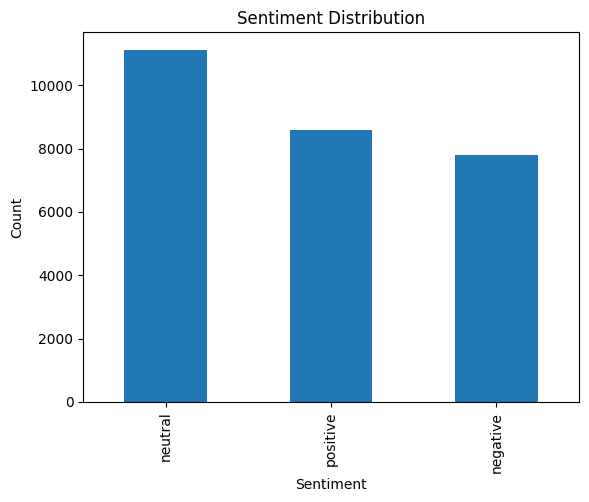

In [6]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Conclusion

This project performs sentiment analysis on Twitter tweets using
Natural Language Processing (NLP) and Machine Learning.

The dataset was preprocessed and converted into numerical features
using CountVectorizer. A Multinomial Naive Bayes classifier was
trained to classify tweets as Positive, Negative, or Neutral.

The model achieved approximately 64% accuracy on the test dataset,
demonstrating the effectiveness of basic NLP techniques for sentiment
classification.
